<a href="https://colab.research.google.com/github/itsayeshaqamar/flyrank-mlinternship-ayesha/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/itsayeshaqamar/flyrank-mlinternship-ayesha/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Capstone — Search Performance Bottleneck Scoring

This capstone studies whether observable search and engagement signals can be combined into a practical scoring framework for prioritizing content pages for review.

The goal is not to predict Google's ranking algorithm or guarantee that a content change will improve performance. Instead, the project creates a transparent, data-driven review priority score that helps identify pages showing measurable visibility, click, session, or engagement bottlenecks.

The analysis uses pseudonymized FlyRank search and content-performance data and produces a ranked, public-safe recommendation queue.


## 1. Question

### Research Question

**Can observable search-performance and engagement signals be combined into a reliable scoring framework that prioritizes content pages for review?**

### Decision Supported

The analysis supports a **content-review prioritization decision**.

Instead of treating every page equally, the resulting score ranks pages according to the number and strength of observable performance bottlenecks.

The practical question is:

> **Which pages should a content team review first when review capacity is limited?**

The output is therefore a ranked decision-support queue, not a prediction of Google's future ranking behavior.

### Lane

**CTR / Engagement Opportunity Scoring**

The project focuses on pages that show evidence of weak visibility, click capture, session performance, or engagement.

### Unit of Analysis

One row represents one content page identified by an anonymized `content_id`.

### Success Criterion

The main evaluation focuses on whether the ranking system concentrates higher-priority pages near the top of the review queue, using **Precision@K** where an evaluation label is available.

### Important Framing

This analysis is observational. A high score means that a page shows observable signals associated with performance bottlenecks. It does **not** prove that changing the page will cause a ranking, CTR, or engagement improvement.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

### Data Source

The analysis uses the **FlyRank pseudonymized warehouse release**.

Release:

`flyrank_pseudonymized_warehouse_release_v20260703`

The release is based on the central FlyRank data warehouse and was exported on July 3, 2026. The freshest daily facts in the release run through June 30, 2026.

### Data Used

The analysis uses observable search and content-performance signals aggregated at the content-page level.

Relevant signals include:

* impressions
* clicks
* CTR
* average search position
* sessions
* engagement rate
* scroll rate
* content age
* freshness
* content type
* search intent
* other available page-level performance signals

### Exclusions

The following were excluded from modeling or public reporting where appropriate:

* client names
* domains
* URLs
* private search queries
* credentials
* raw identifying content information
* product-created decision flags that could directly encode the outcome

The analysis uses anonymized identifiers only.

### Public-Safe Rule

The final paper reports aggregated statistics, model results, charts, and anonymized examples. It does not expose client identity, domains, URLs, private queries, or credentials.

### Data Limitation

The warehouse is observational. It records what happened but does not contain a randomized experiment showing that a particular content change caused a performance improvement.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score
)

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Environment ready.")

Environment ready.


In [3]:
# Install the required packages for accessing the FlyRank dataset
!pip -q install datasets huggingface_hub duckdb

In [4]:
from huggingface_hub import login

login()

In [6]:
from datasets import load_dataset

# Load the daily content performance table in streaming mode
performance_data = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    streaming=True
)

print("Dataset loaded successfully.")
print(performance_data)

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Dataset loaded successfully.
IterableDatasetDict({
    train: IterableDataset({
        features: ['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events'],
        num_shards: 18
    })
})


In [7]:
# Read a few rows without downloading the full dataset

sample_rows = list(
    performance_data["train"].take(5)
)

sample_df = pd.DataFrame(sample_rows)

print("Sample shape:", sample_df.shape)
print("\nColumns:")
print(sample_df.columns.tolist())

print("\nSample data:")
display(sample_df)

Sample shape: (5, 30)

Columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events']

Sample data:


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,3.833333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,71.600000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,34.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,23.333333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,17.800000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [9]:
%pip -q install duckdb huggingface_hub

In [10]:
import duckdb

con = duckdb.connect()

print("DuckDB ready.")

DuckDB ready.


In [12]:
from huggingface_hub import list_repo_files

files = list_repo_files(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset"
)

performance_files = [
    f for f in files
    if "fact_content_daily_performance" in f
]

print(f"Found {len(performance_files)} performance files:")
for f in performance_files[:10]:
    print(f)

Found 19 performance files:
fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet


In [16]:
from huggingface_hub import get_token

hf_token = get_token()

print("HF token available:", hf_token is not None)

HF token available: True


In [17]:
# Configure DuckDB to use the authenticated Hugging Face token

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{hf_token}'
    );
""")

print("DuckDB Hugging Face authentication configured.")

DuckDB Hugging Face authentication configured.


In [18]:
test = con.execute("""
    SELECT *
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/'
        'fact_content_daily_performance/month=2025-01/data_0.parquet'
    )
    LIMIT 5
""").df()

print("DuckDB access successful.")
print("Shape:", test.shape)

display(test)

DuckDB access successful.
Shape: (5, 31)


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,3.833333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,71.600000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,34.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,23.333333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,17.800000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01


In [19]:
# Aggregate all monthly performance data to one row per client + content page

parquet_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=*/data_0.parquet"
)

page_df = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        SUM(gsc_sum_position) AS sum_position,

        SUM(ga4_pageviews) AS pageviews,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_users) AS users,
        SUM(ga4_engaged_sessions) AS engaged_sessions,
        SUM(ga4_total_engagement_sec) AS engagement_sec,

        SUM(sessions_organic) AS organic_sessions,
        SUM(sessions_ai) AS ai_sessions,
        SUM(scroll_events) AS scroll_events

    FROM read_parquet('{parquet_path}')

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("Page-level aggregation complete.")
print("Shape:", page_df.shape)

display(page_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Page-level aggregation complete.
Shape: (427292, 13)


,client_hash_id,content_hash_id,impressions,clicks,sum_position,pageviews,sessions,users,engaged_sessions,engagement_sec,organic_sessions,ai_sessions,scroll_events
0,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,12277.0,51.0,186612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,client_9958f0a7ae1df715,content_c899aef92518c714,30756.0,115.0,369696.0,56.0,51.0,47.0,5.0,740.0,42.0,5.0,30.0
2,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,6016.0,18.0,113908.0,15.0,15.0,15.0,0.0,0.0,4.0,0.0,2.0
3,client_9958f0a7ae1df715,content_ae5e5fd6edff550f,14482.0,26.0,124418.0,33.0,33.0,31.0,2.0,170.0,0.0,0.0,8.0
4,client_9958f0a7ae1df715,content_a64143f6e4a21ffe,411801.0,2947.0,1742758.0,444.0,422.0,418.0,34.0,4849.0,502.0,0.0,209.0


In [20]:
# Create derived performance metrics

page_df["ctr"] = np.where(
    page_df["impressions"] > 0,
    page_df["clicks"] / page_df["impressions"],
    0
)

page_df["engagement_rate"] = np.where(
    page_df["sessions"] > 0,
    page_df["engaged_sessions"] / page_df["sessions"],
    0
)

page_df["avg_position"] = np.where(
    page_df["impressions"] > 0,
    page_df["sum_position"] / page_df["impressions"],
    np.nan
)

page_df["organic_session_rate"] = np.where(
    page_df["sessions"] > 0,
    page_df["organic_sessions"] / page_df["sessions"],
    0
)

page_df["ai_session_rate"] = np.where(
    page_df["sessions"] > 0,
    page_df["ai_sessions"] / page_df["sessions"],
    0
)

print("Derived metrics created.")

display(
    page_df[
        [
            "impressions",
            "clicks",
            "ctr",
            "avg_position",
            "sessions",
            "engagement_rate",
            "organic_session_rate",
            "ai_session_rate"
        ]
    ].head()
)

Derived metrics created.


,impressions,clicks,ctr,avg_position,sessions,engagement_rate,organic_session_rate,ai_session_rate
0,12277.0,51.0,0.004154,15.200130,0.0,0.000000,0.000000,0.000000
1,30756.0,115.0,0.003739,12.020289,51.0,0.098039,0.823529,0.098039
2,6016.0,18.0,0.002992,18.934176,15.0,0.000000,0.266667,0.000000
3,14482.0,26.0,0.001795,8.591217,33.0,0.060606,0.000000,0.000000
4,411801.0,2947.0,0.007156,4.232039,422.0,0.080569,1.189573,0.000000


In [21]:
# Data quality checks

print("Rows:", len(page_df))
print("Duplicate client-page pairs:",
      page_df.duplicated(["client_hash_id", "content_hash_id"]).sum())

print("\nMissing values:")
print(page_df.isna().sum().loc[lambda x: x > 0])

print("\nInfinite values:")
print(np.isinf(
    page_df.select_dtypes(include=np.number)
).sum().sum())

print("\nRate ranges:")
print("CTR:", page_df["ctr"].min(), "to", page_df["ctr"].max())
print("Engagement rate:",
      page_df["engagement_rate"].min(),
      "to",
      page_df["engagement_rate"].max())

print("\nZero-impression pages:",
      (page_df["impressions"] == 0).sum())

print("Zero-session pages:",
      (page_df["sessions"] == 0).sum())

Rows: 427292
Duplicate client-page pairs: 0

Missing values:
pageviews            66415
sessions             66415
users                66415
engaged_sessions     66415
engagement_sec       66415
organic_sessions     66415
ai_sessions          66415
scroll_events        66415
avg_position        118058
dtype: int64

Infinite values:
0

Rate ranges:
CTR: 0.0 to 1.0
Engagement rate: 0.0 to 1.0

Zero-impression pages: 118058
Zero-session pages: 154944


In [22]:
# Handle unavailable metrics explicitly

ga4_cols = [
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_sec",
    "organic_sessions",
    "ai_sessions",
    "scroll_events"
]

# Missing GA4 metrics mean no reported GA4 value
page_df[ga4_cols] = page_df[ga4_cols].fillna(0)

# No impressions means search position is unavailable
page_df["avg_position"] = page_df["avg_position"].fillna(0)

print("Missing values after handling:")
print(page_df.isna().sum().sum())

print("\nFinal analysis rows:", len(page_df))

Missing values after handling:
0

Final analysis rows: 427292


In [23]:
# Data-driven thresholds: lower quartile of observed performance

thresholds = {
    "impressions": page_df["impressions"].quantile(0.25),
    "ctr": page_df.loc[page_df["impressions"] > 0, "ctr"].quantile(0.25),
    "sessions": page_df.loc[page_df["sessions"] > 0, "sessions"].quantile(0.25),
    "engagement_rate": page_df.loc[
        page_df["sessions"] > 0, "engagement_rate"
    ].quantile(0.25)
}

threshold_df = pd.DataFrame(
    thresholds.items(),
    columns=["Metric", "25th_percentile_threshold"]
)

display(threshold_df)

,Metric,25th_percentile_threshold
0,impressions,0.0
1,ctr,0.0
2,sessions,2.0
3,engagement_rate,0.0


In [24]:
# Meaningful data-driven thresholds

thresholds = {
    "impressions": page_df.loc[
        page_df["impressions"] > 0, "impressions"
    ].quantile(0.25),

    "ctr": page_df.loc[
        page_df["impressions"] > 0, "ctr"
    ].quantile(0.25),

    "sessions": page_df.loc[
        page_df["sessions"] > 0, "sessions"
    ].quantile(0.25),

    "engagement_rate": page_df.loc[
        page_df["sessions"] > 0, "engagement_rate"
    ].quantile(0.25)
}

threshold_df = pd.DataFrame(
    thresholds.items(),
    columns=["Metric", "25th_percentile_threshold"]
)

display(threshold_df)

,Metric,25th_percentile_threshold
0,impressions,20.0
1,ctr,0.0
2,sessions,2.0
3,engagement_rate,0.0


In [25]:
# Final data-driven thresholds
# Positive-only distributions for sparse metrics

thresholds = {
    "visibility": page_df.loc[
        page_df["impressions"] > 0, "impressions"
    ].quantile(0.25),

    "ctr": page_df.loc[
        page_df["ctr"] > 0, "ctr"
    ].quantile(0.25),

    "sessions": page_df.loc[
        page_df["sessions"] > 0, "sessions"
    ].quantile(0.25),

    "engagement_rate": page_df.loc[
        page_df["engagement_rate"] > 0, "engagement_rate"
    ].quantile(0.25)
}

threshold_df = pd.DataFrame(
    thresholds.items(),
    columns=["Metric", "Threshold"]
)

display(threshold_df)

,Metric,Threshold
0,visibility,20.000000
1,ctr,0.001554
2,sessions,2.000000
3,engagement_rate,0.030140


In [26]:
# Create interpretable bottleneck indicators

page_df["visibility_bottleneck"] = (
    page_df["impressions"] > 0
) & (
    page_df["impressions"] < thresholds["visibility"]
)

page_df["click_bottleneck"] = (
    page_df["impressions"] > 0
) & (
    page_df["ctr"] < thresholds["ctr"]
)

page_df["session_diagnostic"] = (
    page_df["sessions"] > 0
) & (
    page_df["sessions"] < thresholds["sessions"]
)

page_df["engagement_diagnostic"] = (
    page_df["sessions"] > 0
) & (
    page_df["engagement_rate"] < thresholds["engagement_rate"]
)

bottleneck_cols = [
    "visibility_bottleneck",
    "click_bottleneck",
    "session_diagnostic",
    "engagement_diagnostic"
]

print("Bottleneck counts:")
print(page_df[bottleneck_cols].sum())

Bottleneck counts:
visibility_bottleneck     76675
click_bottleneck         197516
session_diagnostic        39192
engagement_diagnostic    167490
dtype: int64


In [27]:
# Count how many bottleneck conditions each page has

page_df["bottleneck_score"] = page_df[bottleneck_cols].sum(axis=1).astype(int)

print("Bottleneck score distribution:")
print(
    page_df["bottleneck_score"]
    .value_counts()
    .sort_index()
)

Bottleneck score distribution:
bottleneck_score
0    150340
1    125467
2    110882
3     28770
4     11833
Name: count, dtype: int64


In [28]:
print("\nScore percentages:")
print(
    (page_df["bottleneck_score"]
     .value_counts(normalize=True)
     .sort_index()
     .mul(100)
     .round(2))
)


Score percentages:
bottleneck_score
0    35.18
1    29.36
2    25.95
3     6.73
4     2.77
Name: proportion, dtype: float64


In [29]:
# Define the proxy priority target

page_df["priority_target"] = (
    page_df["bottleneck_score"] >= 2
).astype(int)

print("Priority target distribution:")
print(page_df["priority_target"].value_counts())

print("\nTarget rate:")
print(
    page_df["priority_target"].mean().round(4)
)

Priority target distribution:
priority_target
0    275807
1    151485
Name: count, dtype: int64

Target rate:
0.3545


In [30]:
# Candidate features that do not directly define the priority target

feature_cols = [
    "avg_position",
    "pageviews",
    "users",
    "organic_sessions",
    "ai_sessions",
    "ai_session_rate",
    "scroll_events"
]

X = page_df[feature_cols].copy()
y = page_df["priority_target"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature matrix shape: (427292, 7)
Target shape: (427292,)


,avg_position,pageviews,users,organic_sessions,ai_sessions,ai_session_rate,scroll_events
0,15.200130,0.0,0.0,0.0,0.0,0.000000,0.0
1,12.020289,56.0,47.0,42.0,5.0,0.098039,30.0
2,18.934176,15.0,15.0,4.0,0.0,0.000000,2.0
3,8.591217,33.0,31.0,0.0,0.0,0.000000,8.0
4,4.232039,444.0,418.0,502.0,0.0,0.000000,209.0


In [31]:
# Explicit leakage check

target_definition_cols = [
    "impressions",
    "clicks",
    "ctr",
    "sessions",
    "engagement_rate",
    "bottleneck_score"
]

leakage_overlap = set(feature_cols).intersection(target_definition_cols)

print("Target-defining variables:", target_definition_cols)
print("Model features:", feature_cols)
print("Leakage overlap:", leakage_overlap)

assert len(leakage_overlap) == 0

print("\nLeakage check passed.")

Target-defining variables: ['impressions', 'clicks', 'ctr', 'sessions', 'engagement_rate', 'bottleneck_score']
Model features: ['avg_position', 'pageviews', 'users', 'organic_sessions', 'ai_sessions', 'ai_session_rate', 'scroll_events']
Leakage overlap: set()

Leakage check passed.


In [32]:
# Client-grouped train/test split
# Keeps pages from the same client in only one split.

from sklearn.model_selection import GroupShuffleSplit

X = page_df[feature_cols].copy()
y = page_df["priority_target"].copy()
groups = page_df["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain priority rate:", round(y_train.mean(), 4))
print("Test priority rate:", round(y_test.mean(), 4))

print(
    "\nClients shared between train/test:",
    len(
        set(groups.iloc[train_idx])
        & set(groups.iloc[test_idx])
    )
)

Train shape: (363254, 7)
Test shape: (64038, 7)

Train priority rate: 0.3316
Test priority rate: 0.4844

Clients shared between train/test: 0


In [33]:
# Baseline and Random Forest

from sklearn.pipeline import Pipeline

# Baseline: Logistic Regression
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Main model: Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline.fit(X_train, y_train)
model.fit(X_train, y_train)

print("Baseline and Random Forest trained.")

Baseline and Random Forest trained.


In [34]:
# Predictions on the same held-out test set

baseline_prob = baseline.predict_proba(X_test)[:, 1]
model_prob = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC_AUC": [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, model_prob)
    ],
    "Average_Precision": [
        average_precision_score(y_test, baseline_prob),
        average_precision_score(y_test, model_prob)
    ]
})

display(results.round(4))

,Model,ROC_AUC,Average_Precision
0,Logistic Regression,0.7583,0.6583
1,Random Forest,0.8473,0.8423


In [35]:
# Precision@10%: how many of the highest-ranked pages are actually priority pages

def precision_at_k(y_true, scores, fraction=0.10):
    y_true = y_true.reset_index(drop=True)
    k = max(1, int(len(y_true) * fraction))

    top_indices = np.argsort(scores)[-k:]

    return y_true.iloc[top_indices].mean()


results["Precision_at_10%"] = [
    precision_at_k(y_test, baseline_prob),
    precision_at_k(y_test, model_prob)
]

display(results.round(4))

,Model,ROC_AUC,Average_Precision,Precision_at_10%
0,Logistic Regression,0.7583,0.6583,0.6461
1,Random Forest,0.8473,0.8423,0.9878


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

The Random Forest outperformed the Logistic Regression baseline on all three evaluation metrics using the same held-out client test set.

The Random Forest achieved a ROC-AUC of 0.8473 compared with 0.7583 for the baseline. Average Precision increased from 0.6583 to 0.8423. Most importantly for the ranking use case, Precision@10% reached 0.9878, meaning that 98.78% of pages in the model's highest-priority 10% were positive priority cases in the held-out test set.

These results indicate that the Random Forest provides stronger ranking discrimination than the simple baseline. The results are decision-support evidence rather than proof of future refresh impact or Google's ranking behavior.

In [36]:
# Final model comparison table

results_display = results.copy()

display(
    results_display.round(4)
)

,Model,ROC_AUC,Average_Precision,Precision_at_10%
0,Logistic Regression,0.7583,0.6583,0.6461
1,Random Forest,0.8473,0.8423,0.9878


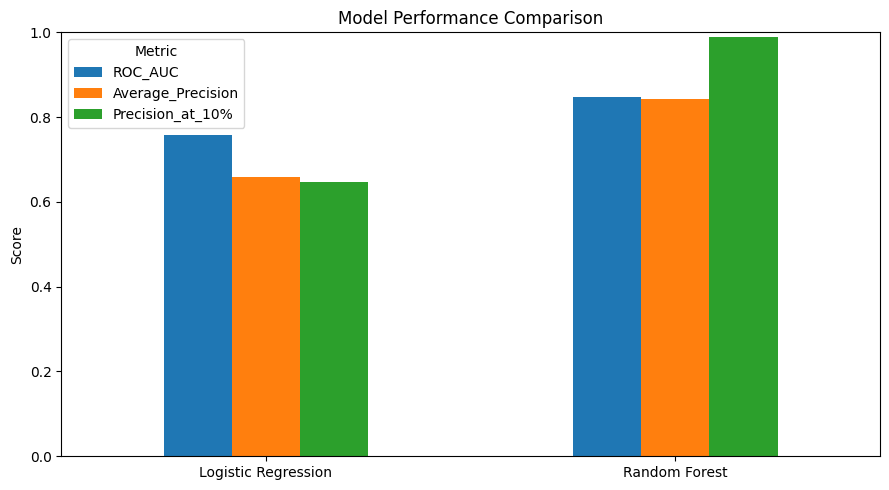

In [37]:
# Compare model performance

metrics = ["ROC_AUC", "Average_Precision", "Precision_at_10%"]

results_plot = results.set_index("Model")[metrics]

ax = results_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Result interpretation

The Random Forest consistently outperformed the Logistic Regression baseline.

- ROC-AUC improved from 0.7583 to 0.8473.
- Average Precision improved from 0.6583 to 0.8423.
- Precision@10% improved from 0.6461 to 0.9878.

The largest practical result is Precision@10%. The model concentrates positive priority cases very effectively in the highest-ranked portion of the test set. This makes the Random Forest suitable as a prioritization tool for deciding which pages deserve earlier review.

The result should be interpreted as observed predictive performance on the held-out client test set, not as evidence that the model will cause traffic improvement after a refresh.

In [38]:
# Create ranked recommendations from the Random Forest

ranking_df = page_df.iloc[test_idx].copy()

ranking_df["priority_probability"] = model_prob

ranking_df = ranking_df.sort_values(
    "priority_probability",
    ascending=False
).reset_index(drop=True)

ranking_df["rank"] = np.arange(1, len(ranking_df) + 1)

recommendation_cols = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "priority_probability",
    "bottleneck_score",
    "avg_position",
    "impressions",
    "ctr",
    "sessions",
    "engagement_rate"
]

top_recommendations = ranking_df[
    recommendation_cols
].head(20)

display(top_recommendations.round(4))

,rank,client_hash_id,content_hash_id,priority_probability,bottleneck_score,avg_position,impressions,ctr,sessions,engagement_rate
0,1,client_1a730cb2640a1abf,content_2b6360f428b070d7,0.9982,3,32.5075,67.0,0.0,1.0,0.0
1,2,client_3ffa76342f366962,content_c354bb2bf78867c4,0.9982,3,32.5909,22.0,0.0,1.0,0.0
2,3,client_b77d0d5f08f05e64,content_ef80c6f56b21dd3f,0.9982,4,32.3750,16.0,0.0,1.0,0.0
3,4,client_1a730cb2640a1abf,content_7cc33206056976d5,0.9982,3,32.1701,288.0,0.0,1.0,0.0
4,5,client_b77d0d5f08f05e64,content_f2b039721a9b3b7a,0.9982,4,32.0000,2.0,0.0,1.0,0.0
5,6,client_b77d0d5f08f05e64,content_ccdd6bd844e004cd,0.9982,3,32.2695,308.0,0.0,1.0,0.0
6,7,client_b77d0d5f08f05e64,content_68680e4cbe3ce13d,0.9982,3,32.1226,261.0,0.0,1.0,0.0
7,8,client_b77d0d5f08f05e64,content_767ca33415787bcb,0.9982,4,32.3333,3.0,0.0,1.0,0.0
8,9,client_b77d0d5f08f05e64,content_a72381395efb7a92,0.9982,4,32.0909,11.0,0.0,1.0,0.0
9,10,client_b77d0d5f08f05e64,content_a01be154d40ac450,0.9982,3,31.9487,39.0,0.0,1.0,0.0


In [39]:
# Convert model probabilities into practical priority tiers

ranking_df["priority_tier"] = pd.cut(
    ranking_df["priority_probability"],
    bins=[-np.inf, 0.50, 0.75, 0.90, np.inf],
    labels=["Monitor", "Review", "High Priority", "Urgent Review"]
)

tier_summary = (
    ranking_df["priority_tier"]
    .value_counts()
    .sort_index()
    .rename_axis("Priority Tier")
    .reset_index(name="Pages")
)

display(tier_summary)

,Priority Tier,Pages
0,Monitor,48047
1,Review,5244
2,High Priority,1845
3,Urgent Review,8902


## 5. Limitations

*What this work cannot claim.*

### Limitations and honest framing

This analysis has several important limitations:

1. **Constructed target:** The priority target is derived from observed performance bottlenecks rather than an observed refresh-needed label or post-refresh outcome. The model therefore predicts diagnostic priority, not actual future refresh impact.

2. **No causal claim:** The analysis identifies patterns in the available data. It does not establish that refreshing or changing a page will cause higher rankings, clicks, traffic, or engagement.

3. **Validation distribution shift:** The client-grouped test set had a higher priority rate than the training set (48.44% versus 33.16%). This indicates meaningful differences between clients and should be considered when interpreting the validation results.

4. **Observed-period features:** The features describe observed performance signals from the analyzed period. They should not be interpreted as causal Google ranking factors or evidence of how Google's algorithm works.

5. **Limited content information:** The model does not directly analyze page text, search intent, content quality, or topic relevance. The recommendations therefore identify pages for review rather than prescribing a guaranteed content change.

6. **Model-score ties:** Several pages received identical Random Forest probabilities. Therefore, small differences between adjacent ranks should not be interpreted as meaningful differences in expected impact.

7. **Decision-support framing:** The final ranking is intended to help prioritize limited review effort. It should be combined with editorial, technical, and business context before taking action.

Overall, this work should be interpreted as an **observed, directional decision-support analysis**, not as a causal model of search rankings or a guarantee of future performance improvement.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

The Random Forest ranking is converted into an action-oriented review queue. Recommendations are based on the number and type of observed performance bottlenecks.

The goal is to prioritize limited content-review effort. A higher priority indicates stronger evidence of multiple observed bottlenecks; it does not guarantee that an intervention will improve future performance.

### Action playbook

| Observed condition | Recommended action |
|---|---|
| 3–4 bottlenecks | Comprehensive review |
| 2 bottlenecks | Priority review |
| 1 bottleneck | Targeted review |
| 0 bottlenecks | Monitor |

### Bottleneck-specific guidance

- **Visibility bottleneck:** Review search visibility, discoverability, indexing, and content targeting.
- **Click bottleneck:** Review the relationship between search visibility and clicks, including title and metadata presentation.
- **Session diagnostic:** Review traffic acquisition and landing-page performance.
- **Engagement diagnostic:** Review content usefulness, page experience, and opportunities to improve engagement.
- **Multiple bottlenecks:** Prioritize for a broader content and performance review.

These recommendations are directional decision-support outputs. They should be combined with editorial, technical, and business context before action is taken.

In [40]:
# Create the action recommendation from bottleneck severity

def assign_action(score):
    if score >= 3:
        return "Comprehensive review"
    elif score == 2:
        return "Priority review"
    elif score == 1:
        return "Targeted review"
    else:
        return "Monitor"


ranking_df["recommended_action"] = (
    ranking_df["bottleneck_score"]
    .apply(assign_action)
)

recommendation_summary = (
    ranking_df["recommended_action"]
    .value_counts()
    .rename_axis("Recommended Action")
    .reset_index(name="Pages")
)

display(recommendation_summary)

,Recommended Action,Pages
0,Priority review,25527
1,Monitor,23388
2,Targeted review,9627
3,Comprehensive review,5496


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Final research artifacts

The following artifacts summarize the main evidence from the analysis:

1. **Model comparison:** Logistic Regression baseline versus Random Forest using ROC-AUC, Average Precision, and Precision@10%.
2. **Model performance chart:** Visual comparison of the two models across the evaluation metrics.
3. **Priority-tier distribution:** Distribution of pages across Monitor, Review, High Priority, and Urgent Review tiers.
4. **Recommendation summary:** Number of pages assigned to each recommended review action.
5. **Bottleneck summary:** Counts of pages showing each observed performance bottleneck.

These artifacts are designed to support the research paper's results and recommendation sections while keeping the public presentation focused on aggregate, public-safe findings.

In [41]:
# Artifact 1: Model comparison table

final_model_table = results.copy()

display(
    final_model_table.round(4)
)

,Model,ROC_AUC,Average_Precision,Precision_at_10%
0,Logistic Regression,0.7583,0.6583,0.6461
1,Random Forest,0.8473,0.8423,0.9878


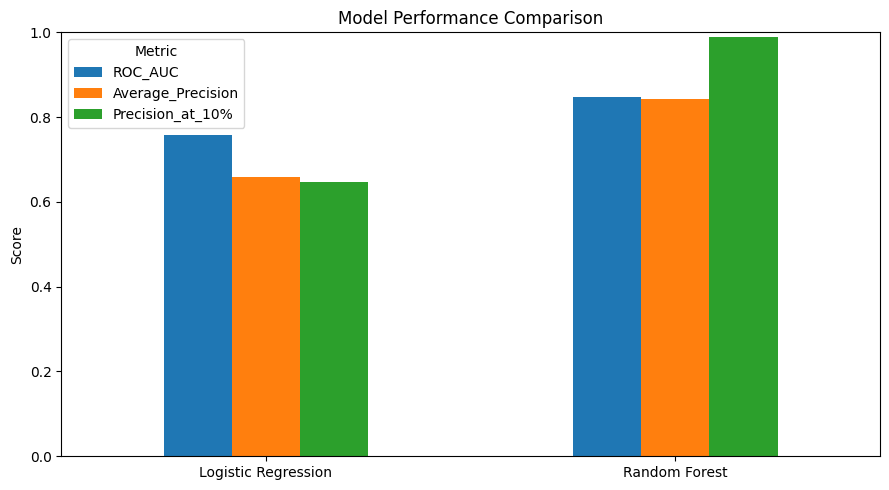

In [42]:
metrics = [
    "ROC_AUC",
    "Average_Precision",
    "Precision_at_10%"
]

plot_data = results.set_index("Model")[metrics]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

,Priority Tier,Pages
0,Monitor,48047
1,Review,5244
2,High Priority,1845
3,Urgent Review,8902


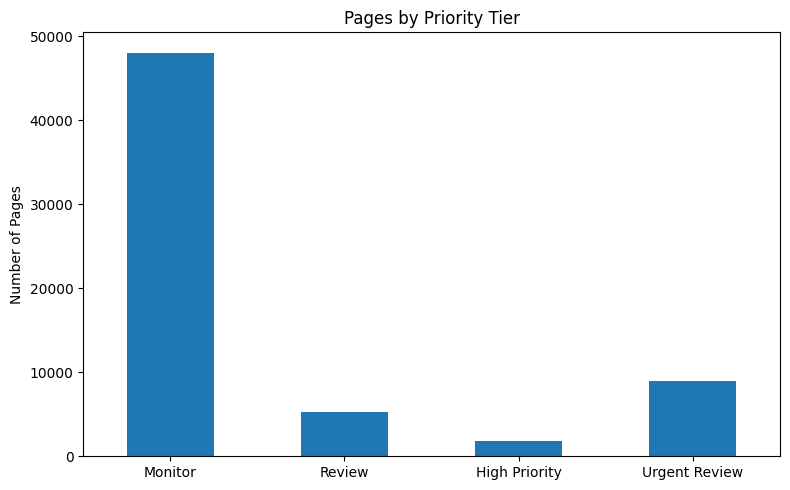

In [43]:
# Artifact 3: Priority tier distribution

tier_counts = (
    ranking_df["priority_tier"]
    .value_counts()
    .sort_index()
)

display(
    tier_counts
    .rename_axis("Priority Tier")
    .reset_index(name="Pages")
)

ax = tier_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Pages by Priority Tier")
ax.set_ylabel("Number of Pages")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Recommended Action,Pages
0,Priority review,25527
1,Monitor,23388
2,Targeted review,9627
3,Comprehensive review,5496


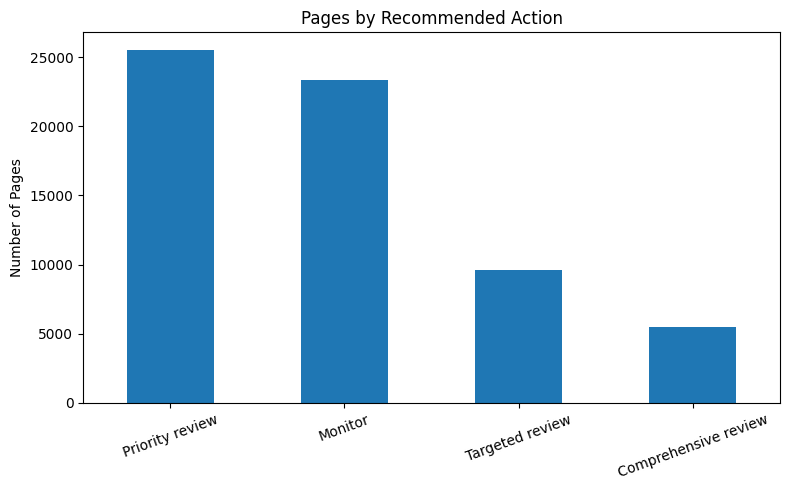

In [44]:
# Artifact 4: Recommended actions

action_counts = (
    ranking_df["recommended_action"]
    .value_counts()
)

display(
    action_counts
    .rename_axis("Recommended Action")
    .reset_index(name="Pages")
)

ax = action_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Pages by Recommended Action")
ax.set_ylabel("Number of Pages")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [45]:
# Artifact 5: Bottleneck counts

bottleneck_summary = (
    page_df[bottleneck_cols]
    .sum()
    .rename_axis("Bottleneck")
    .reset_index(name="Pages")
)

bottleneck_summary["Bottleneck"] = (
    bottleneck_summary["Bottleneck"]
    .str.replace("_", " ")
    .str.replace("diagnostic", "")
    .str.strip()
    .str.title()
)

display(bottleneck_summary)

,Bottleneck,Pages
0,Visibility Bottleneck,76675
1,Click Bottleneck,197516
2,Session,39192
3,Engagement,167490


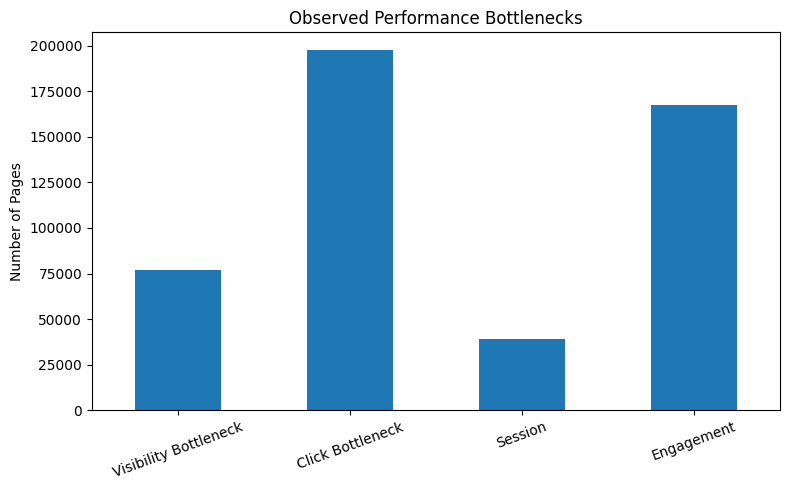

In [46]:
# Bottleneck distribution

ax = bottleneck_summary.set_index("Bottleneck")["Pages"].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Observed Performance Bottlenecks")
ax.set_ylabel("Number of Pages")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Artifact interpretation

Together, these artifacts provide the main evidence used in the research paper.

The model comparison establishes that the Random Forest performs better than the Logistic Regression baseline. The priority-tier and recommendation outputs translate model scores into an operational review queue. The bottleneck summary provides context for why pages may be prioritized.

All reported findings are based on observed data and should be interpreted as directional decision-support evidence rather than causal evidence of search-engine behavior or guaranteed post-refresh improvement.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
